# Phase 3 :- EDA

In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
# Loading cleaned datasets

account = pd.read_csv('/Users/soujanyaprokashsingha/Documents/Data Analyst_Science/Professional Projects/Datamites Projects/Bank_Credit_Risk_Prediction/data/processed/account_cleaned.csv')

enquiry = pd.read_csv('/Users/soujanyaprokashsingha/Documents/Data Analyst_Science/Professional Projects/Datamites Projects/Bank_Credit_Risk_Prediction/data/processed/enquiry_cleaned.csv')

demo = pd.read_csv('/Users/soujanyaprokashsingha/Documents/Data Analyst_Science/Professional Projects/Datamites Projects/Bank_Credit_Risk_Prediction/data/processed/demo_cleaned.csv')

In [3]:
# Converting dates again

date_cols_account = [
    'opened_dt',
    'last_paymt_dt',
    'closed_dt',
    'reporting_dt',
    'paymt_str_dt',
    'paymt_end_dt'
]

for col in date_cols_account:
    account[col] = pd.to_datetime(account[col], errors='coerce')

In [4]:
# Target variable

demo['bad_label'].value_counts()

bad_label
0    967
1     33
Name: count, dtype: int64

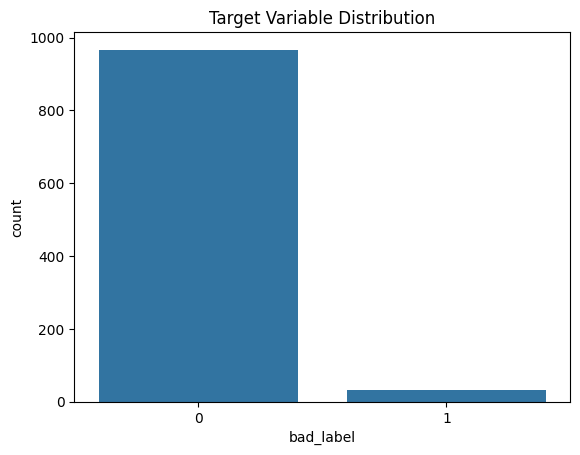

In [5]:
# Target distribution visualization

sns.countplot(x='bad_label', data=demo)

plt.title('Target Variable Distribution')

plt.show()

In [6]:
# Percentage distribution

demo['bad_label'].value_counts(normalize=True)*100

bad_label
0    96.7
1     3.3
Name: proportion, dtype: float64

In [7]:
# Summary (account dataset)

account[['creditlimit',
         'cur_balance_amt',
         'amt_past_due',
         'high_credit_amt']].describe()

,creditlimit,cur_balance_amt,amt_past_due,high_credit_amt
count,235.000000,9.950000e+02,5.000000,9.230000e+02
mean,89406.808511,8.439414e+04,11597.200000,1.938784e+05
std,84770.941847,4.864530e+05,19619.944513,6.181981e+05
min,1500.000000,-1.234800e+04,17.000000,1.120000e+02
25%,38500.000000,0.000000e+00,1296.000000,2.304400e+04
50%,64000.000000,0.000000e+00,1986.000000,4.700000e+04
75%,107500.000000,1.649150e+04,8485.000000,1.338435e+05
max,547000.000000,1.019890e+07,46202.000000,1.150000e+07


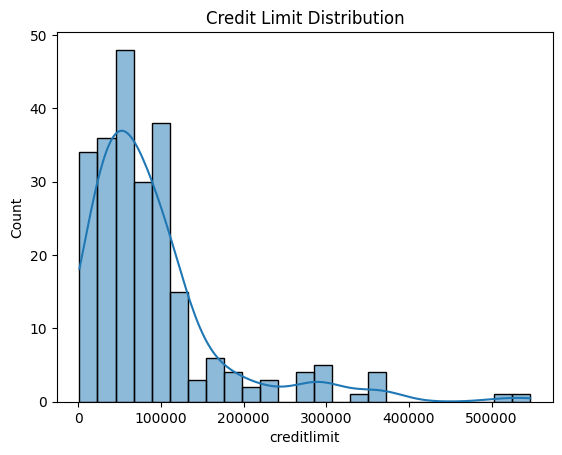

In [8]:
# Numeric distribution visualization

sns.histplot(account['creditlimit'], kde=True)

plt.title('Credit Limit Distribution')

plt.show()

In [9]:
# Analyzing "account type" feature

account['acct_type'].value_counts()

acct_type
10    531
6     146
5     131
1      49
13     44
2      40
0      20
7       9
12      6
3       6
51      5
15      2
8       2
32      1
52      1
4       1
56      1
Name: count, dtype: int64

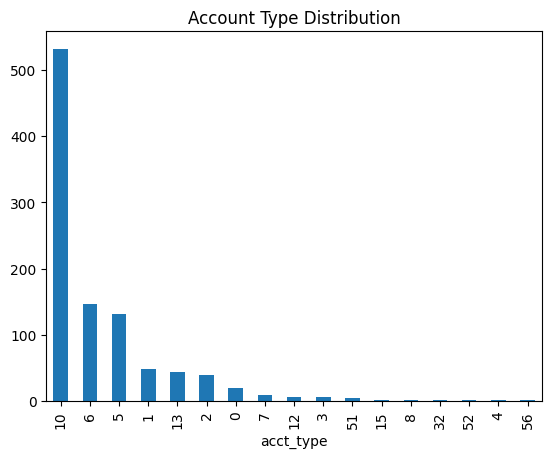

In [10]:
# Visualization

account['acct_type'].value_counts().plot(kind='bar')

plt.title('Account Type Distribution')

plt.show()

In [11]:
# analyzing "Ownership indicator"

account['owner_indic'].value_counts()

owner_indic
1    955
4     30
2     10
Name: count, dtype: int64

In [12]:
# Analyzing "Enquiry Purpose"

enquiry['enq_purpose'].value_counts()

enq_purpose
10.0    280
0.0     156
1.0     125
51.0    114
5.0     108
2.0      79
12.0     25
3.0      14
54.0     11
53.0     10
6.0      10
52.0      6
4.0       6
7.0       4
55.0      3
40.0      2
8.0       2
13.0      2
57.0      1
32.0      1
Name: count, dtype: int64

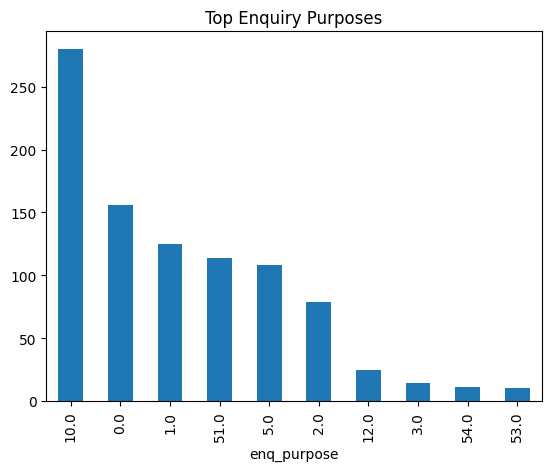

In [13]:
# Visualization

enquiry['enq_purpose'].value_counts().head(10).plot(kind='bar')

plt.title('Top Enquiry Purposes')

plt.show()

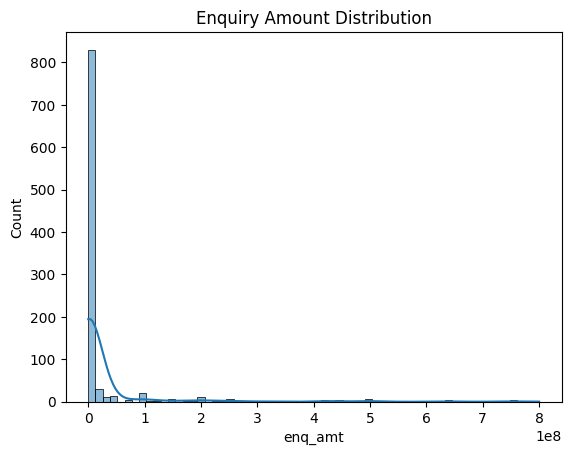

In [14]:
sns.histplot(enquiry['enq_amt'], kde=True)

plt.title('Enquiry Amount Distribution')

plt.show()

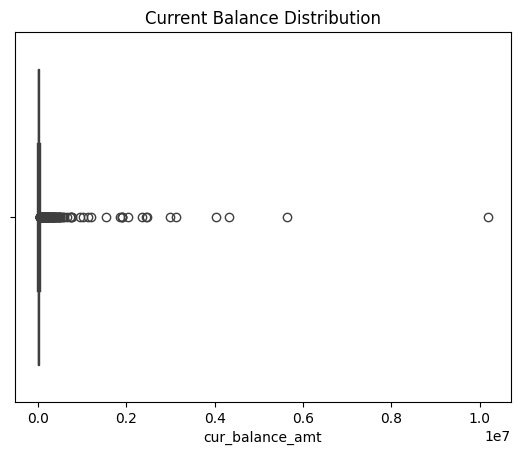

In [15]:
sns.boxplot(x=account['cur_balance_amt'])

plt.title('Current Balance Distribution')

plt.show()

In [16]:
# Creating Credit Utilization Feature

account['credit_utilization'] = (
    account['cur_balance_amt'] /
    account['creditlimit']
)

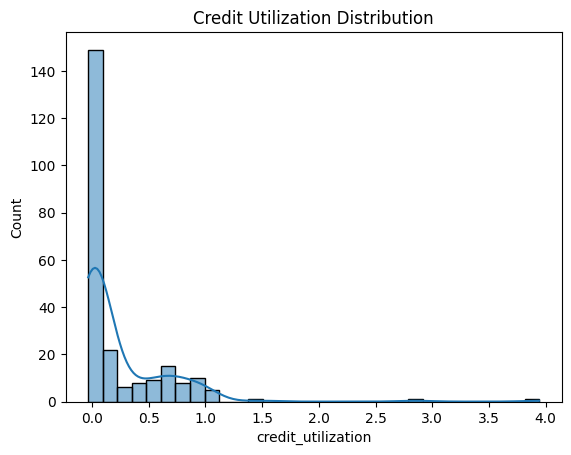

In [17]:
sns.histplot(account['credit_utilization'], kde=True)

plt.title('Credit Utilization Distribution')

plt.show()

In [18]:
# Merging "Demo" data with "Account"
# merging "demo" data with "account" data because the target variable (bad_label) exists in the demo table, 
# while important banking features like "credit_utilization" exist in the account table.

account_demo = pd.merge(
    account,
    demo[['customer_no', 'bad_label']],
    on='customer_no',
    how='left'
)

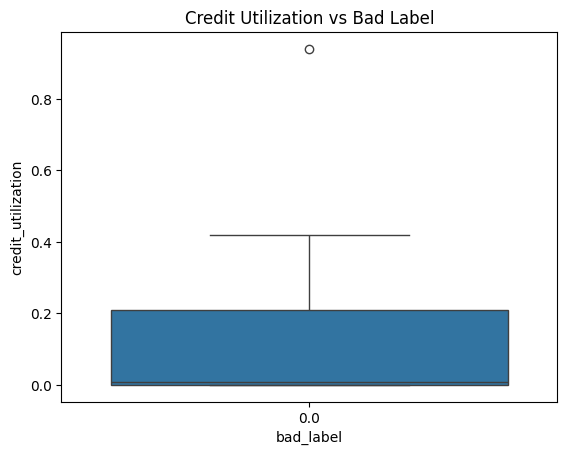

In [19]:
sns.boxplot(
    x='bad_label',
    y='credit_utilization',
    data=account_demo
)

plt.title('Credit Utilization vs Bad Label')

plt.show()

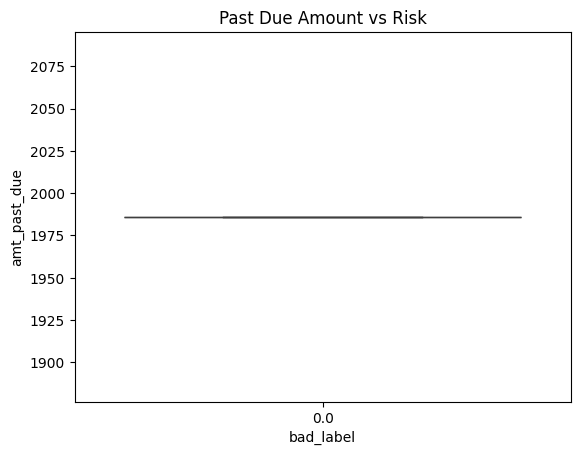

In [20]:
# Analyzing past due amount

sns.boxplot(
    x='bad_label',
    y='amt_past_due',
    data=account_demo
)

plt.title('Past Due Amount vs Risk')

plt.show()

In [21]:
# Payment frequency

account['paymentfrequency'].value_counts()

paymentfrequency
3.0    325
Name: count, dtype: int64

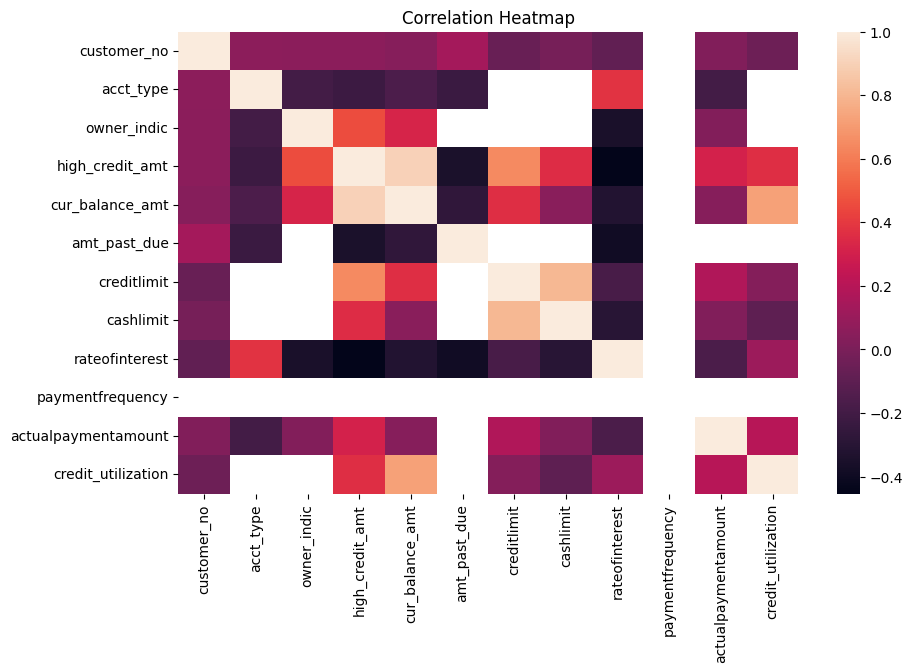

In [23]:
# Correlation heatmap for Numeric columns

numeric_cols = account.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(10,6))

sns.heatmap(corr)

plt.title('Correlation Heatmap')

plt.show()

In [24]:
# Checking the distribution of account

account.groupby('customer_no').size().describe()

count    123.000000
mean       8.089431
std        7.866726
min        1.000000
25%        4.000000
50%        5.000000
75%       10.000000
max       54.000000
dtype: float64

In [25]:
# Checking the distribution of enquiry

enquiry.groupby('customer_no').size().describe()

count     51.000000
mean      18.823529
std       22.811143
min        1.000000
25%        5.000000
50%       11.000000
75%       23.000000
max      114.000000
dtype: float64